# Rag From Scratch: Retrieval
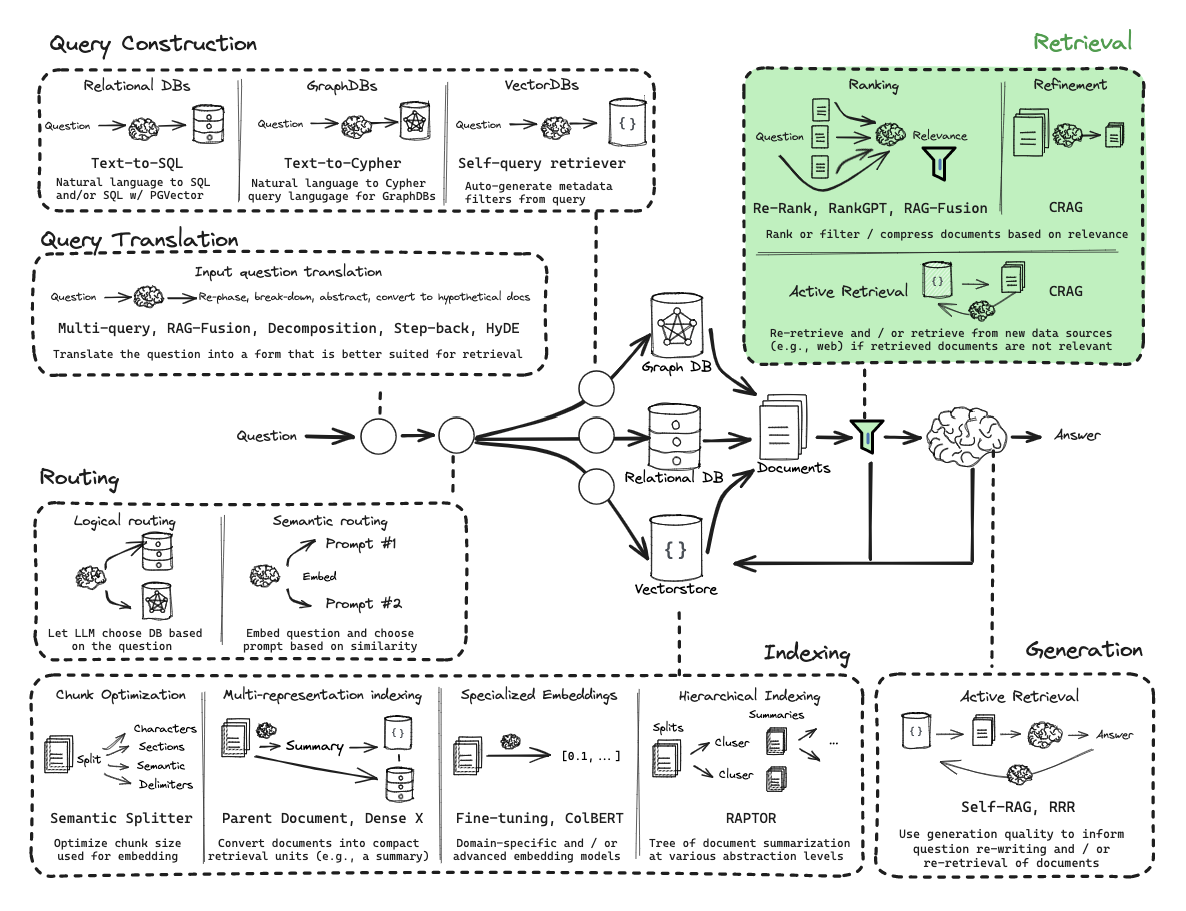

## Environment

In [1]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
# Set a User-Agent for polite web requests (helps with some sites)
os.environ["USER_AGENT"] = "rag-from-scratch/1.0 (+mailto:your-email@example.com)"

## Part 15: Re-ranking

We showed this previously with RAG-fusion.
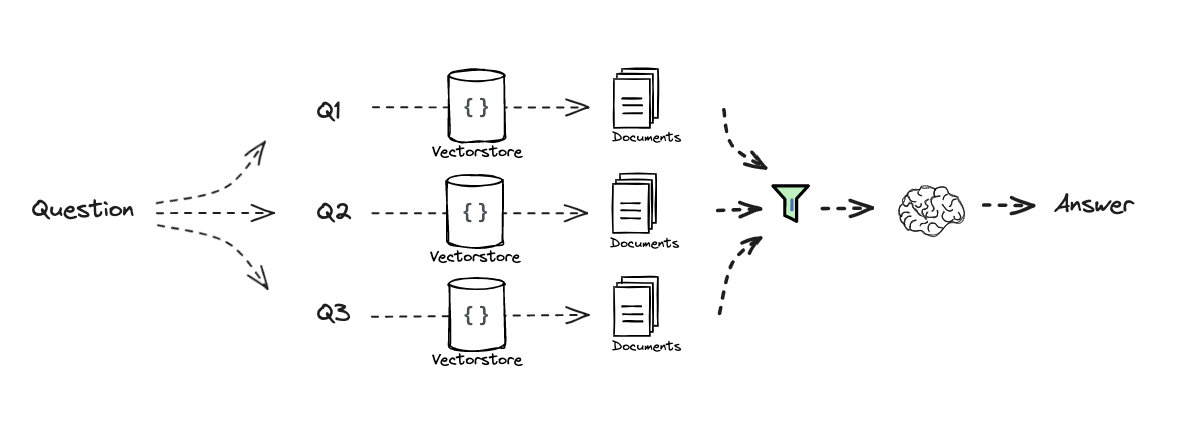

In [12]:
#### INDEXING ####

# Load blog
import bs4
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter



loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)

# chat model
chat_model = ChatOpenAI(
    model="qwen-plus",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    temperature=0,
)

# Make embeddings
qwen_embds = OpenAIEmbeddings(
    model="text-embedding-v3",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    chunk_size=10,
    check_embedding_ctx_length=False,
)

vectorstore = FAISS.from_documents(documents=splits, 
                                    # embedding=CohereEmbeddings()
                                    embedding=qwen_embds)


retriever = vectorstore.as_retriever()

In [11]:
from langchain_core.prompts import ChatPromptTemplate

# RAG-Fusion
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [13]:
from langchain_core.output_parsers import StrOutputParser

generate_queries = (
    prompt_rag_fusion 
    | chat_model
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)


In [19]:
from langchain_core.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k: int = 60):
    """使用 Reciprocal Rank Fusion, RRF, 合并多个排序结果。"""

    fused_scores = {}

    for ranked_documents in results:
        for rank, doc in enumerate(ranked_documents):
            # 把文档转成稳定的字符串表示，方便跨多个结果列表去重。
            doc_key = dumps(doc)

            # 如果这是第一次见到这个文档，就先补一个初始分数。
            if doc_key not in fused_scores:
                fused_scores[doc_key] = 0

            # RRF 的核心：排名越靠前，贡献的分数越高。
            fused_scores[doc_key] += 1 / (rank + k)

    # 按总分从高到低排序，再把字符串还原成原始文档对象。
    reranked_results = [
        (loads(doc_key), score)
        for doc_key, score in sorted(
            fused_scores.items(), key=lambda item: item[1], reverse=True
        )
    ]

    return reranked_results

question = "What is task decomposition for LLM agents?"
retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)


C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_18516\1927228896.py:22: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc_key), score)


10

In [20]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain_rag_fusion, 
     "question": itemgetter("question")} 
    | prompt
    | chat_model
    | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_18516\1927228896.py:22: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc_key), score)


'Task decomposition for LLM agents is the process of breaking down a complex, high-level task into smaller, simpler, and more manageable subgoals or steps. As described in the context, this is a core aspect of the **Planning** component in LLM-powered autonomous agents.\n\nKey points from the text include:\n\n- It enables efficient handling of complicated tasks by decomposing them into sequential or parallel subtasks.\n- It supports interpretability by revealing the agent’s “thinking process” — for example, via **Chain of Thought (CoT)** prompting, where the model is instructed to “think step by step.”\n- Advanced methods like **Tree of Thoughts (ToT)** extend CoT by generating *multiple* reasoning paths at each step and exploring them using search strategies (e.g., BFS or DFS), with states evaluated via prompts or voting.\n- Task decomposition can be performed in several ways:\n  1. **By the LLM itself**, using simple prompts (e.g., *“Steps for XYZ.\\n1.”* or *“What are the subgoals f

We can also use [Cohere Re-Rank](https://python.langchain.com/docs/integrations/retrievers/cohere-reranker#doing-reranking-with-coherererank). 

See [here](https://txt.cohere.com/rerank/):

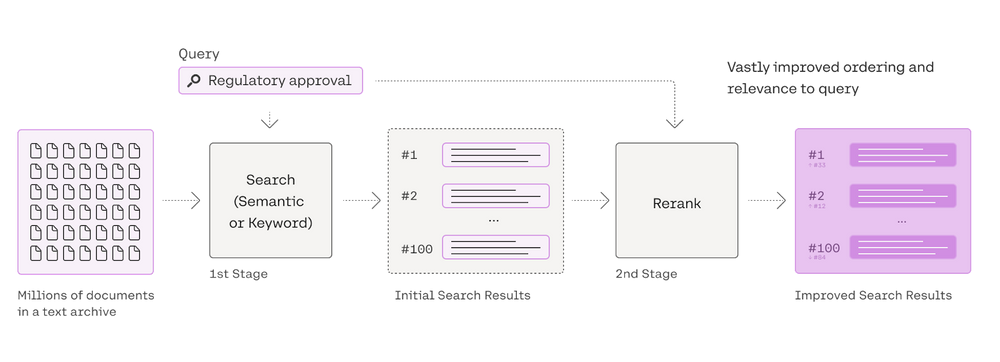


In [ ]:
from langchain_community.llms import Cohere
from langchain_community.llms import Cohere
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CohereRerank

retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# Re-rank
compressor = CohereRerank() # need cohere api key!
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=retriever
)

compressed_docs = compression_retriever.get_relevant_documents(question)

ValidationError: 1 validation error for CohereRerank
  Value error, Did not find cohere_api_key, please add an environment variable `COHERE_API_KEY` which contains it, or pass `cohere_api_key` as a named parameter. [type=value_error, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

## 16 - Retrieval (CRAG)

`Deep Dive`

https://www.youtube.com/watch?v=E2shqsYwxck

`Notebooks`

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_crag.ipynb

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_crag_mistral.ipynb

# Generation



## 17 - Retrieval (Self-RAG)
 
`Notebooks`

https://github.com/langchain-ai/langgraph/tree/main/examples/rag

https://github.com/langchain-ai/langgraph/blob/main/examples/rag/langgraph_self_rag_mistral_nomic.ipynb

## 18 - Impact of long context  

`Deep dive`

https://www.youtube.com/watch?v=SsHUNfhF32s

`Slides`

https://docs.google.com/presentation/d/1mJUiPBdtf58NfuSEQ7pVSEQ2Oqmek7F1i4gBwR6JDss/edit#slide=id.g26c0cb8dc66_0_0